In [ ]:
# Import necessary libraries.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import time
import keras_tuner as kt
import tensorflow as tf
import tensorflow.keras.backend as K
import os

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
LabelEncoder

from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasClassifier

from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, SGD, Adagrad, RMSprop, Adadelta
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.models import Sequential



---
## Data Preprocessing

1. Load Dataset
1. Remove Invalid Column
1. Test Train Validation split
1. Scale the data to aid neural network performance

---

In [ ]:
# Load the dataset from the CSV file into a pandas DataFrame.
#d = pd.read_csv("../Data/NZ_LUCAS_SMAP_NIWA.csv")
df= pd.read_csv("C:\\Python\\COMP661 Deep Learning\\Comp661_Assigment1\\1174976_EcoVision_Project1\\Data\\NZ_LUCAS_SMAP_NIWA.csv")
# Drop the unnecessary column '36' from the dataframe.
df.drop(columns=['36'], inplace=True)

# Target
y = df["soil_organic_carbon_target"]

# Features (Drop soil_organic_carbon_target from the features)
X = df.drop(columns=["soil_organic_carbon_target"])


# Train (70%) / Temp (30%)

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Validation (15%) / Test (15%)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

# Scale the data to aid neural network training.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)


#Verify the shapes of the training, validation, and test sets, as well as the mean and standard deviation of the scaled training set.
print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

print('X_train_scaled mean:', X_train_scaled.mean())
print('X_train_scaled standard deviation:', X_train_scaled.std())

---
### Create Baseline Model

#### Compile the model using:

* Loss Function: Mean Squared Error (MSE)
* Optimizer: Adam (default learning rate)
* Evaluation Metric: Mean Absolute Error (MAE)

#### Train the model using:

* Epochs: 100
* Batch size: 32
* Validation set: created in Part 1

---

In [ ]:


# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

baseline_model = tf.keras.Sequential([
    tf.keras.layers.Dense(
        32,
        activation='relu',
        input_shape=(X_train_scaled.shape[1],)
    ),
    tf.keras.layers.Dense(1)
])

baseline_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = baseline_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

---
### Evaluate baseline model

---

In [ ]:
test_loss, test_mae = baseline_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test MSE:", test_loss)
print("Test MAE:", test_mae)

---
### Training History Plot
---

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

---
Create Resuable Function
---

In [ ]:

def create_dynamic_model(
    num_hidden_layers,
    num_neurons,
    activation_choice,
    optimizer_choice
):

    model = tf.keras.Sequential()

    model.add(
        tf.keras.layers.Input(
            shape=(X_train_scaled.shape[1],)
        )
    )

    for _ in range(num_hidden_layers):
        model.add(
            tf.keras.layers.Dense(
                num_neurons,
                activation=activation_choice
            )
        )

    model.add(tf.keras.layers.Dense(1))

    model.compile(
        optimizer=optimizer_choice,
        loss='mse',
        metrics=['mae']
    )

    return model

In [ ]:




#Arrays for testing loop to be commented out for final submission
#hidden_layers = [1, 2]
#num_neurons = [8, 16]
#activation_array = ['relu', 'tanh']
#optimizer_choice = ['adam', 'sgd']
"""""
for h in hidden_layers:
    print(f"Training model with {h} hidden layers...")
    for n in num_neurons:
        print(f"Number of neurons: {n}")
    for a in activation_array:
        print(f"Activation function: {a}")
    for o in optimizer_choice:
        print(f"Optimizer: {o}")
        model = create_dynamic_model(num_hidden_layers=h , num_neurons=n, activation_choice=a, optimizer_choice=o)
        
        history = model.fit(
            X_train_scaled,
            y_train,
            validation_data=(X_val_scaled, y_val),
        epochs=100,
        batch_size=32,
        verbose=1
    )
    
    test_loss, test_mae = model.evaluate(
        X_test_scaled,
        y_test,
        verbose=0
    )
    
    print(f"Test MSE for {h} hidden layers: {test_loss}")
    print(f"Test MAE for {h} hidden layers: {test_mae}")
    
    plt.figure(figsize=(10,5))
    
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title(f"Training vs Validation Loss for {h} Hidden Layers")
    plt.legend()
    
    plt.show()

    """


Training model with 1 hidden layers...
Epoch 1/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3825.8494 - mae: 61.1402 - val_loss: 3629.8894 - val_mae: 59.4707
Epoch 2/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3404.4749 - mae: 57.6175 - val_loss: 3132.9719 - val_mae: 55.1840
Epoch 3/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2800.2520 - mae: 52.1440 - val_loss: 2428.7456 - val_mae: 48.4467
Epoch 4/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2020.8770 - mae: 44.0430 - val_loss: 1612.8864 - val_mae: 39.1482
Epoch 5/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1241.0182 - mae: 33.9479 - val_loss: 908.9096 - val_mae: 28.5972
Test MSE for 1 hidden layers: 948.7083129882812
Test MAE for 1 hidden layers: 29.373815536499023


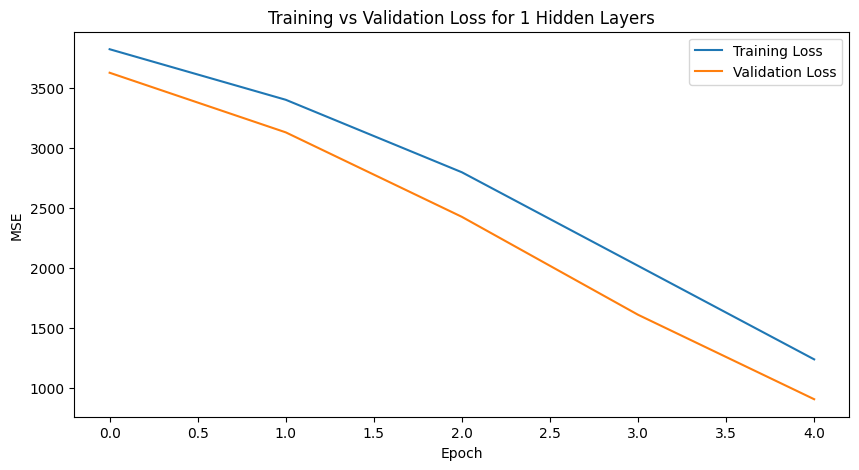

Training model with 2 hidden layers...
Epoch 1/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3161.2498 - mae: 55.1056 - val_loss: 1795.9950 - val_mae: 41.1467
Epoch 2/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 659.7536 - mae: 21.6584 - val_loss: 149.8868 - val_mae: 9.9004
Epoch 3/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 125.9985 - mae: 9.0205 - val_loss: 115.8132 - val_mae: 8.5436
Epoch 4/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 102.7878 - mae: 8.1270 - val_loss: 104.6241 - val_mae: 8.1293
Epoch 5/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 91.1173 - mae: 7.6426 - val_loss: 96.3423 - val_mae: 7.8082
Test MSE for 2 hidden layers: 83.05751037597656
Test MAE for 2 hidden layers: 7.175734519958496


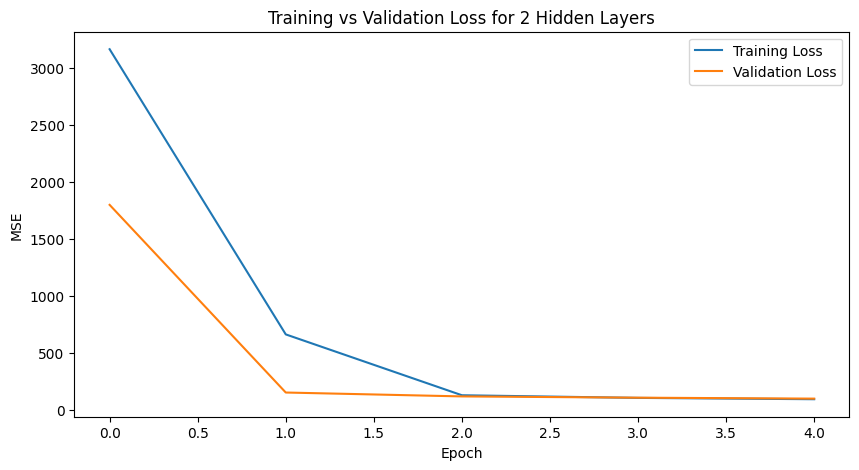

Training model with 3 hidden layers...
Epoch 1/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2985.0242 - mae: 52.0969 - val_loss: 345.4352 - val_mae: 15.5411
Epoch 2/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 145.6906 - mae: 9.5975 - val_loss: 117.4462 - val_mae: 8.6741
Epoch 3/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 94.4659 - mae: 7.8106 - val_loss: 100.3036 - val_mae: 7.9351
Epoch 4/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 80.3121 - mae: 7.1845 - val_loss: 89.5589 - val_mae: 7.4989
Epoch 5/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 70.2581 - mae: 6.7092 - val_loss: 81.4431 - val_mae: 7.1653
Test MSE for 3 hidden layers: 80.40259552001953
Test MAE for 3 hidden layers: 7.25355863571167


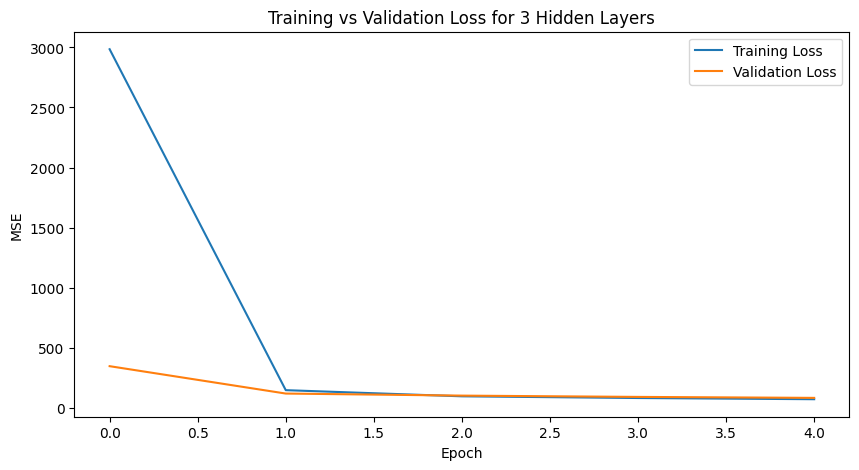

Training model with 4 hidden layers...
Epoch 1/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1892.0671 - mae: 36.5700 - val_loss: 144.3246 - val_mae: 9.7166
Epoch 2/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 112.7286 - mae: 8.4778 - val_loss: 102.3918 - val_mae: 8.0846
Epoch 3/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 88.4985 - mae: 7.5184 - val_loss: 89.5227 - val_mae: 7.5104
Epoch 4/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 74.5094 - mae: 6.8859 - val_loss: 79.7738 - val_mae: 7.0938
Epoch 5/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 64.1381 - mae: 6.3749 - val_loss: 71.8950 - val_mae: 6.7633
Test MSE for 4 hidden layers: 63.4052848815918
Test MAE for 4 hidden layers: 6.29266881942749


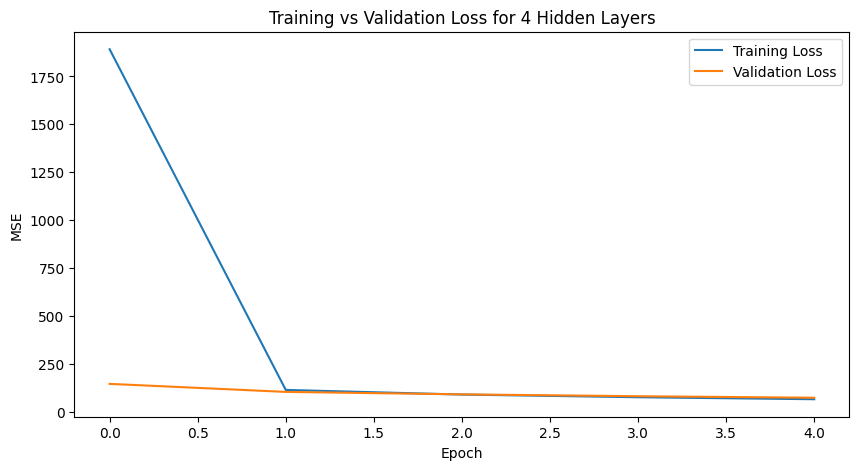

Results for different hidden layers:
              Variable Validation MSE Validation MAE
0  Hidden Layers Depth                              
1                  1.0     948.708313      29.373816
2                  2.0       83.05751       7.175735
3                  3.0      80.402596       7.253559
4                  4.0      63.405285       6.292669


In [ ]:

# Hidden layers loop
hidden_layers = [1, 2, 3, 4]


results_df = pd.DataFrame(
    results,
    columns=[
        "Variable",
        "Validation MSE",
        "Validation MAE"
    ]
)
results_df = results_df.iloc[0:0]
results_df.loc[len(results_df)] = ['Hidden Layers Depth', '', '']
for h in hidden_layers:
    print(f"Training model with {h} hidden layers...")
    model = create_dynamic_model(num_hidden_layers=h , num_neurons=32, activation_choice='relu', optimizer_choice='adam')
        
    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=100,
        #epochs=5,
        batch_size=32,
        verbose=1
    )
    
    test_loss, test_mae = model.evaluate(
        X_test_scaled,
        y_test,
        verbose=0
    )
    
    print(f"Test MSE for {h} hidden layers: {test_loss}")
    print(f"Test MAE for {h} hidden layers: {test_mae}")
    
    plt.figure(figsize=(10,5))
    
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title(f"Training vs Validation Loss for {h} Hidden Layers")
    plt.legend()
    plt.show()
    # Add row to results dataframe
    results_df.loc[len(results_df)] = [h, test_loss, test_mae]



print("Results for different hidden layers:")
print(results_df)




Training model with 4 hidden layers...
Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3980.7019 - mae: 62.3739 - val_loss: 3833.3303 - val_mae: 61.1610
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3704.3391 - mae: 60.1781 - val_loss: 3530.1746 - val_mae: 58.6957
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3366.1812 - mae: 57.3610 - val_loss: 3156.8196 - val_mae: 55.4887
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2958.9980 - mae: 53.7494 - val_loss: 2720.0742 - val_mae: 51.4500
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2494.9500 - mae: 49.2723 - val_loss: 2237.6641 - val_mae: 46.5309
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2001.3696 - mae: 43.9500 - val_loss: 1749.5154 - val_mae: 40.8696
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1525.9653 - mae: 38.0209 - val_loss: 1303.1857 - val_mae: 34.7779
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1109.2467 -

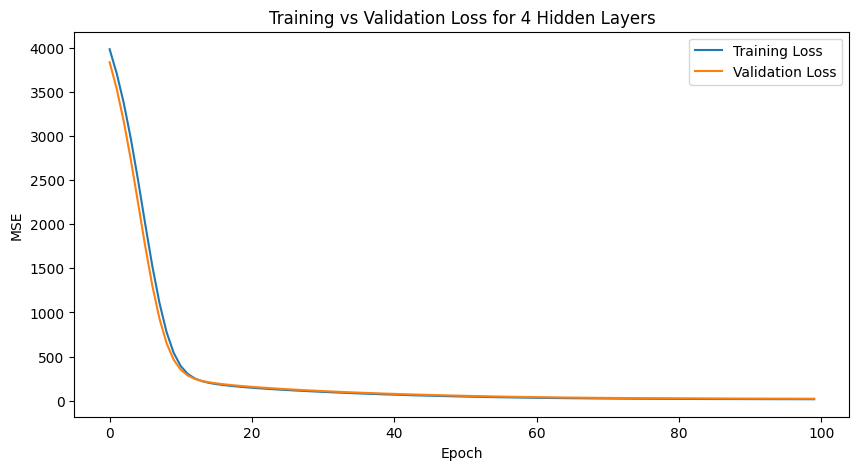

Training model with 4 hidden layers...
Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3958.6313 - mae: 62.2036 - val_loss: 3744.9810 - val_mae: 60.4377
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3535.2949 - mae: 58.7620 - val_loss: 3267.9182 - val_mae: 56.4364
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2992.3621 - mae: 54.0176 - val_loss: 2659.0774 - val_mae: 50.8396
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2340.7705 - mae: 47.6189 - val_loss: 1976.4951 - val_mae: 43.5883
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1668.1158 - mae: 39.7625 - val_loss: 1333.2561 - val_mae: 35.1544
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1091.8375 - mae: 31.2897 - val_loss: 839.5866 - val_mae: 26.7345
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 685.8163 - mae: 23.8195 - val_loss: 529.0042 - val_mae: 20.3552
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 444.3705 - mae

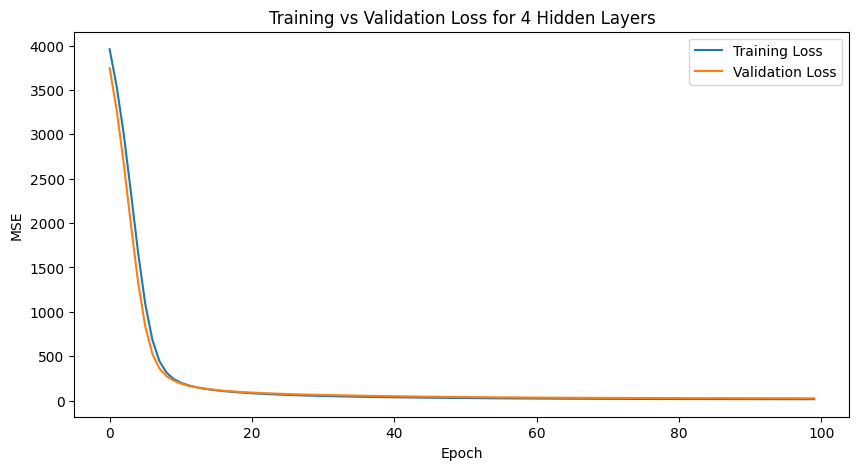

Training model with 4 hidden layers...
Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3765.0103 - mae: 60.6430 - val_loss: 3430.3323 - val_mae: 57.8484
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3056.7954 - mae: 54.6065 - val_loss: 2594.5068 - val_mae: 50.2950
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2127.3433 - mae: 45.4007 - val_loss: 1611.7756 - val_mae: 39.4024
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1200.9104 - mae: 33.5075 - val_loss: 803.1627 - val_mae: 26.8903
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 560.7623 - mae: 21.6904 - val_loss: 358.2349 - val_mae: 16.6656
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 260.1873 - mae: 13.8326 - val_loss: 196.8054 - val_mae: 11.8118
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 161.4552 - mae: 10.4671 - val_loss: 152.6999 - val_mae: 10.0581
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 131.5938 - mae: 9.

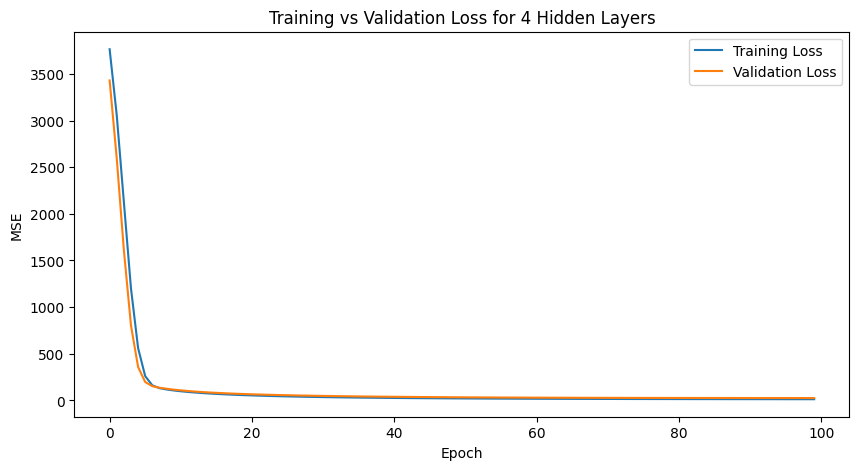

Training model with 4 hidden layers...
Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3622.8191 - mae: 59.4293 - val_loss: 3094.8003 - val_mae: 54.8537
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2435.0505 - mae: 48.4440 - val_loss: 1667.5890 - val_mae: 39.9849
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1049.2407 - mae: 30.8199 - val_loss: 523.9236 - val_mae: 20.9476
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 307.8170 - mae: 15.2663 - val_loss: 179.6692 - val_mae: 11.2377
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 145.2939 - mae: 9.8621 - val_loss: 132.0346 - val_mae: 9.3714
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 115.9128 - mae: 8.6385 - val_loss: 115.8465 - val_mae: 8.7271
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 100.6578 - mae: 8.0132 - val_loss: 103.8576 - val_mae: 8.2504
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 89.2107 - mae: 7.5269 - va

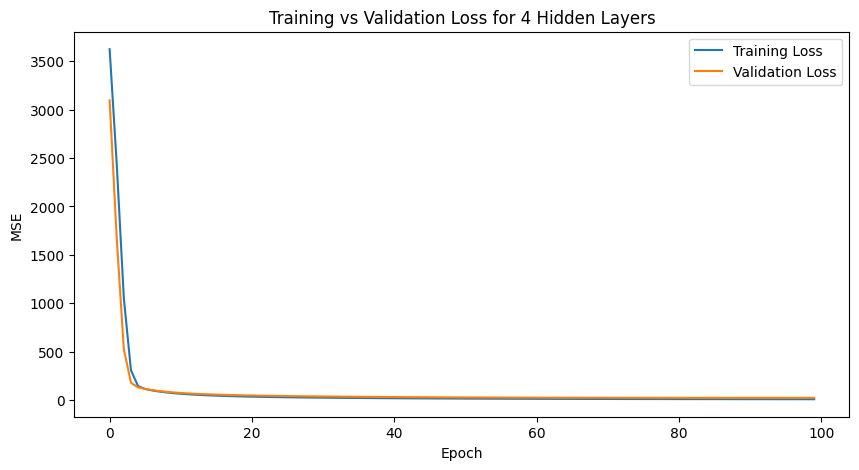

Results for different hidden layers:
               Variable Validation MSE Validation MAE
0   Hidden Layers Depth                              
1                   1.0     948.708313      29.373816
2                   2.0       83.05751       7.175735
3                   3.0      80.402596       7.253559
4                   4.0      63.405285       6.292669
5     Number of Neurons                              
6     Number of Neurons                              
7                  16.0      21.886364       3.655851
8                  32.0      25.417578       4.007732
9                  64.0      24.725199       3.984018
10                128.0       24.13275       3.885377


In [ ]:
depth_winner = 1
num_neurons = [16, 32, 64, 128]

results_df.loc[len(results_df)] = ['Number of Neurons', '', '']
for n in num_neurons:
    print(f"Training model with {n} number of neurons...")
    model = create_dynamic_model(num_hidden_layers=depth_winner , num_neurons=n, activation_choice='relu', optimizer_choice='adam')
        
    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=100,
        batch_size=32,
        verbose=1
    )
    
    test_loss, test_mae = model.evaluate(
        X_test_scaled,
        y_test,
        verbose=0
    )
    
    print(f"Test MSE for {h} hidden layers: {test_loss}")
    print(f"Test MAE for {h} hidden layers: {test_mae}")
    
    plt.figure(figsize=(10,5))
    
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title(f"Training vs Validation Loss for {h} Hidden Layers")
    plt.legend()
    plt.show()
    results_df.loc[len(results_df)] = [n, test_loss, test_mae]

print("Results for different hidden layers:")
print(results_df)



Training model with relu activation function...
Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3955.1858 - mae: 62.1596 - val_loss: 3868.0134 - val_mae: 61.4150
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3780.6655 - mae: 60.7617 - val_loss: 3679.2554 - val_mae: 59.8867
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3570.4939 - mae: 59.0303 - val_loss: 3450.4934 - val_mae: 57.9770
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3318.1492 - mae: 56.8750 - val_loss: 3179.6704 - val_mae: 55.6230
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3027.0054 - mae: 54.2680 - val_loss: 2873.6689 - val_mae: 52.8196
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2706.6104 - mae: 51.2213 - val_loss: 2544.8013 - val_mae: 49.6004
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2371.0642 - mae: 47.7855 - val_loss: 2208.6965 - val_mae: 46.0341
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 20

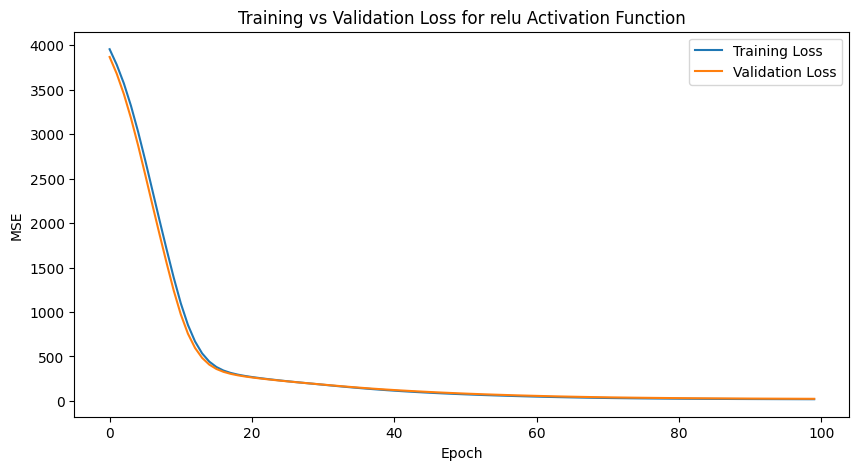

Training model with tanh activation function...
Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4045.5991 - mae: 62.9140 - val_loss: 4019.7837 - val_mae: 62.6722
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3997.1836 - mae: 62.5589 - val_loss: 3964.7166 - val_mae: 62.2665
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3927.4951 - mae: 62.0375 - val_loss: 3878.6470 - val_mae: 61.6150
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3815.7148 - mae: 61.1709 - val_loss: 3738.2800 - val_mae: 60.5032
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3642.5776 - mae: 59.7622 - val_loss: 3533.4131 - val_mae: 58.7901
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3415.2720 - mae: 57.8089 - val_loss: 3288.0447 - val_mae: 56.6201
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3178.6072 - mae: 55.6729 - val_loss: 3063.6797 - val_mae: 54.5507
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 29

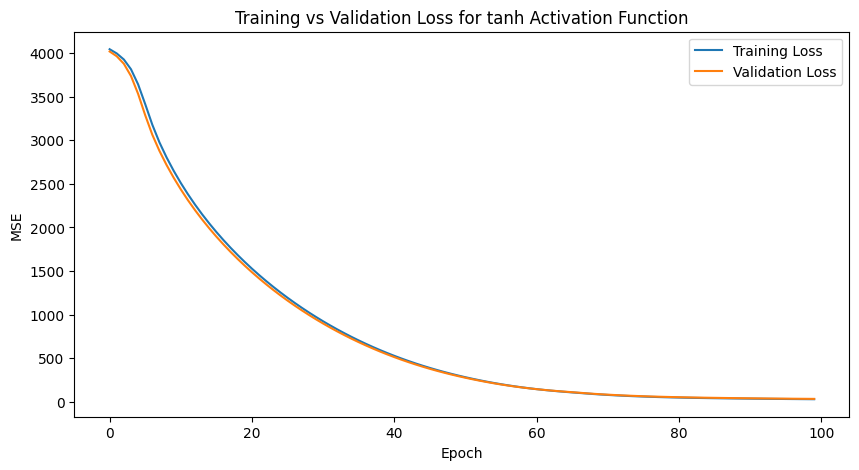

Results for different activation functions:
               Variable Validation MSE Validation MAE
0   Hidden Layers Depth                              
1                   1.0     948.708313      29.373816
2                   2.0       83.05751       7.175735
3                   3.0      80.402596       7.253559
4                   4.0      63.405285       6.292669
5     Number of Neurons                              
6     Number of Neurons                              
7                  16.0      21.886364       3.655851
8                  32.0      25.417578       4.007732
9                  64.0      24.725199       3.984018
10                128.0       24.13275       3.885377
11  Activation Function                              
12                 relu      22.332502       3.766798
13                 tanh       31.18261       4.227231


In [37]:
neurons_winner = 8
activation_array = ['relu', 'tanh']
results_df.loc[len(results_df)] = ['Activation Function', '', '']
for a in activation_array:
    print(f"Training model with {a} activation function...")
    model = create_dynamic_model(num_hidden_layers=depth_winner , num_neurons=neurons_winner, activation_choice=a, optimizer_choice='adam')
        
    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=100,
        batch_size=32,
        verbose=1
    )
    
    test_loss, test_mae = model.evaluate(
        X_test_scaled,
        y_test,
        verbose=0
    )
    
    print(f"Test MSE for {a} activation function: {test_loss}")
    print(f"Test MAE for {a} activation function: {test_mae}")
    
    plt.figure(figsize=(10,5))
    
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title(f"Training vs Validation Loss for {a} Activation Function")
    plt.legend()
    plt.show()
    results_df.loc[len(results_df)] = [a, test_loss, test_mae]

print("Results for different activation functions:")
print(results_df)

Training model with adam optimizer...
Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4007.6902 - mae: 62.5569 - val_loss: 3924.2156 - val_mae: 61.8280
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3868.4182 - mae: 61.4156 - val_loss: 3779.4033 - val_mae: 60.6194
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3708.2817 - mae: 60.0642 - val_loss: 3594.5496 - val_mae: 59.0293
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3492.6323 - mae: 58.1919 - val_loss: 3342.5244 - val_mae: 56.7899
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3205.2161 - mae: 55.6081 - val_loss: 3015.3191 - val_mae: 53.7607
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2840.9939 - mae: 52.1749 - val_loss: 2615.2920 - val_mae: 49.8438
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2418.6699 - mae: 47.9059 - val_loss: 2179.4919 - val_mae: 45.1970
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1983.6899 - 

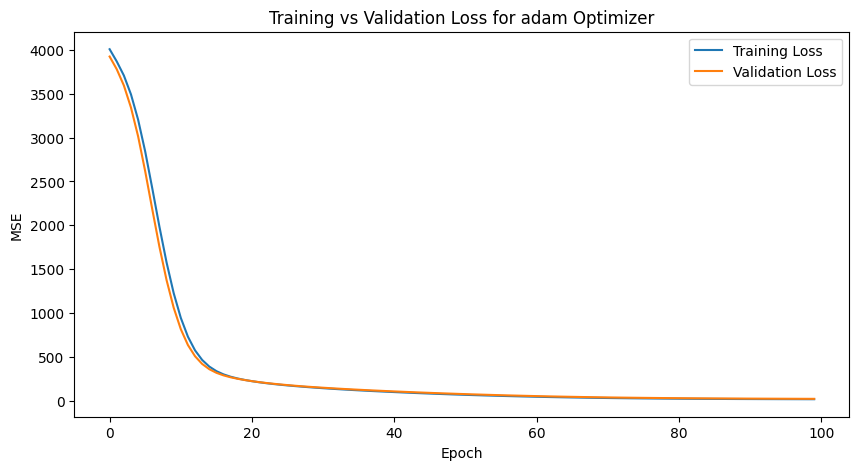

Training model with sgd optimizer...
Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 545.7816 - mae: 17.8938 - val_loss: 509.4277 - val_mae: 17.7750
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 189.9739 - mae: 10.7588 - val_loss: 186.0287 - val_mae: 10.6650
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 97.3192 - mae: 7.7328 - val_loss: 216.8379 - val_mae: 11.7828
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 82.8770 - mae: 7.0760 - val_loss: 48.3047 - val_mae: 5.5770
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 52.2984 - mae: 5.5618 - val_loss: 42.7685 - val_mae: 5.2488
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 46.7191 - mae: 5.2979 - val_loss: 47.8952 - val_mae: 5.4991
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 41.3117 - mae: 4.9854 - val_loss: 36.2323 - val_mae: 4.8122
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 36.5366 - mae: 4.7170 - val_loss: 56.1025 - v

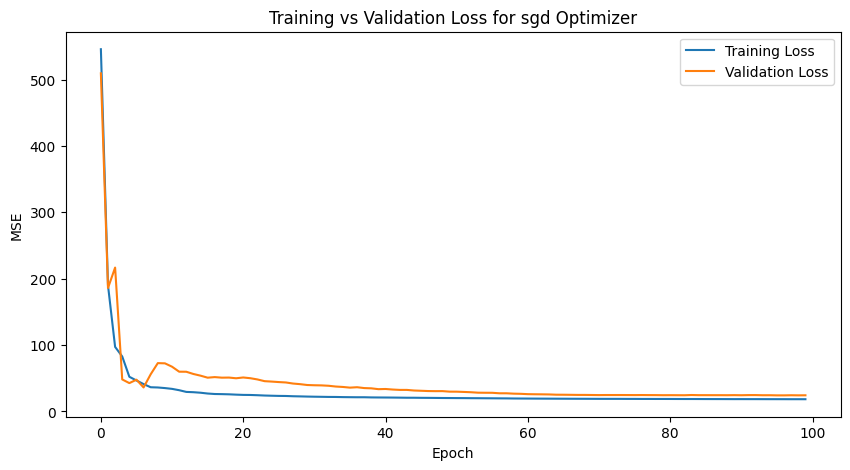

Results for different optimizers:
               Variable Validation MSE Validation MAE
0   Hidden Layers Depth                              
1                   1.0     948.708313      29.373816
2                   2.0       83.05751       7.175735
3                   3.0      80.402596       7.253559
4                   4.0      63.405285       6.292669
5     Number of Neurons                              
6     Number of Neurons                              
7                  16.0      21.886364       3.655851
8                  32.0      25.417578       4.007732
9                  64.0      24.725199       3.984018
10                128.0       24.13275       3.885377
11  Activation Function                              
12                 relu      22.332502       3.766798
13                 tanh       31.18261       4.227231
14            Optimizer                              
15                 adam      23.644781       3.795265
16                  sgd      23.388258       3.8

In [38]:
activation_winner = 'relu'
optimizer_choice = ['adam', 'sgd']

results_df.loc[len(results_df)] = ['Optimizer', '', '']
for o in optimizer_choice:
    print(f"Training model with {o} optimizer...")
    model = create_dynamic_model(num_hidden_layers=depth_winner , num_neurons=neurons_winner, activation_choice=activation_winner, optimizer_choice=o)
        
    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=100,
        batch_size=32,
        verbose=1
    )
    
    test_loss, test_mae = model.evaluate(
        X_test_scaled,
        y_test,
        verbose=0
    )
    
    print(f"Test MSE for {o} optimizer: {test_loss}")
    print(f"Test MAE for {o} optimizer: {test_mae}")
    
    plt.figure(figsize=(10,5))
    
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title(f"Training vs Validation Loss for {o} Optimizer")
    plt.legend()
    plt.show()
    results_df.loc[len(results_df)] = [o, test_loss, test_mae]

print("Results for different optimizers:")
print(results_df)

In [ ]:
print("Best model configuration:")
print(f"Number of hidden layers: {depth_winner}")
print(f"Number of neurons: {neurons_winner}")
print(f"Activation function: {activation_winner}")
print(f"Optimizer: {optimizer_choice}")